## 1. Importing Necessary Packages

In [1]:
# Importing Necessary Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV ,RandomizedSearchCV, cross_val_score
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import  OrdinalEncoder ,StandardScaler
from sklearn.linear_model import Lasso , Ridge
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.metrics import( mean_squared_error , mean_absolute_error , r2_score)
from sklearn.pipeline import Pipeline
import joblib

import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width' , None)
pd.set_option("display.max_colwidth" , 20)



## 2. Importing Data

In [2]:
# Importing data

df = pd.read_csv('/Users/pradyumreddygade/AI ML Course Projects/Lectures/house_price_prediction_dataset.csv')

df = df.drop(columns=['Id'])

print(f"shape:" , df.shape)

print('----')

display(f"Top 5 Rows:" , df.head())



shape: (1460, 80)
----


'Top 5 Rows:'

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3.Exploratory Data Analysis

#### 3A Basic Overview

In [3]:
# Used to check if the datatypes are correct



print(df.info()) 

# MSSubclass . MoSold must be object



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [4]:
# statistical info to check if numbers make sense

df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# checking for null values

print(((df.isnull().sum().sort_values(ascending=False))/ len(df)) * 100)

# will have to drop colums which has more than 40% null values

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageYrBlt       5.547945
GarageCond        5.547945
GarageType        5.547945
GarageFinish      5.547945
GarageQual        5.547945
BsmtExposure      2.602740
BsmtFinType2      2.602740
BsmtCond          2.534247
BsmtQual          2.534247
BsmtFinType1      2.534247
MasVnrArea        0.547945
Electrical        0.068493
MSSubClass        0.000000
Fireplaces        0.000000
Functional        0.000000
KitchenQual       0.000000
KitchenAbvGr      0.000000
BedroomAbvGr      0.000000
HalfBath          0.000000
FullBath          0.000000
BsmtHalfBath      0.000000
TotRmsAbvGrd      0.000000
GarageCars        0.000000
GrLivArea         0.000000
GarageArea        0.000000
PavedDrive        0.000000
WoodDeckSF        0.000000
OpenPorchSF       0.000000
EnclosedPorch     0.000000
3SsnPorch         0.000000
S

In [6]:
# Checking for duplicate values

print(df.duplicated().sum())

# no duplicates to be dropped

0


In [7]:
# Checking the target distribution and skewness of the target variable

print(("Skew:" , df["SalePrice"].skew()))

# The skewness is greater than 1 so it must be log transformed.


('Skew:', np.float64(1.8828757597682129))


#### 3B Distribution of Target Variable

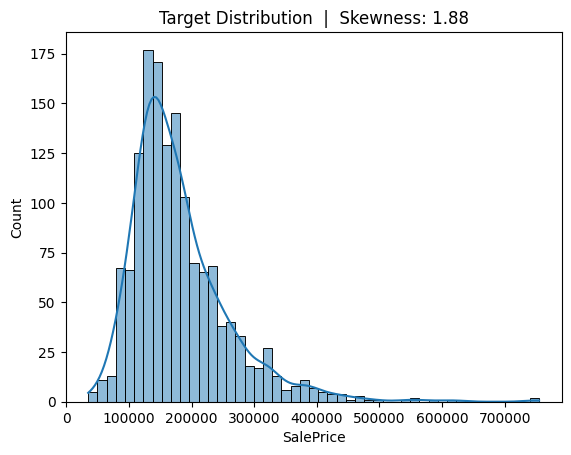

In [8]:
# Plot to show distribution of target variable

skewness = round(df["SalePrice"].skew() ,2)
sns.histplot(df["SalePrice"] , kde= True)
plt.title(f"Target Distribution  |  Skewness: {skewness:.2f}")
plt.show()

# Log transformation is required in feature engineering

#### 3C Distribution of Numerical Feature Distribution



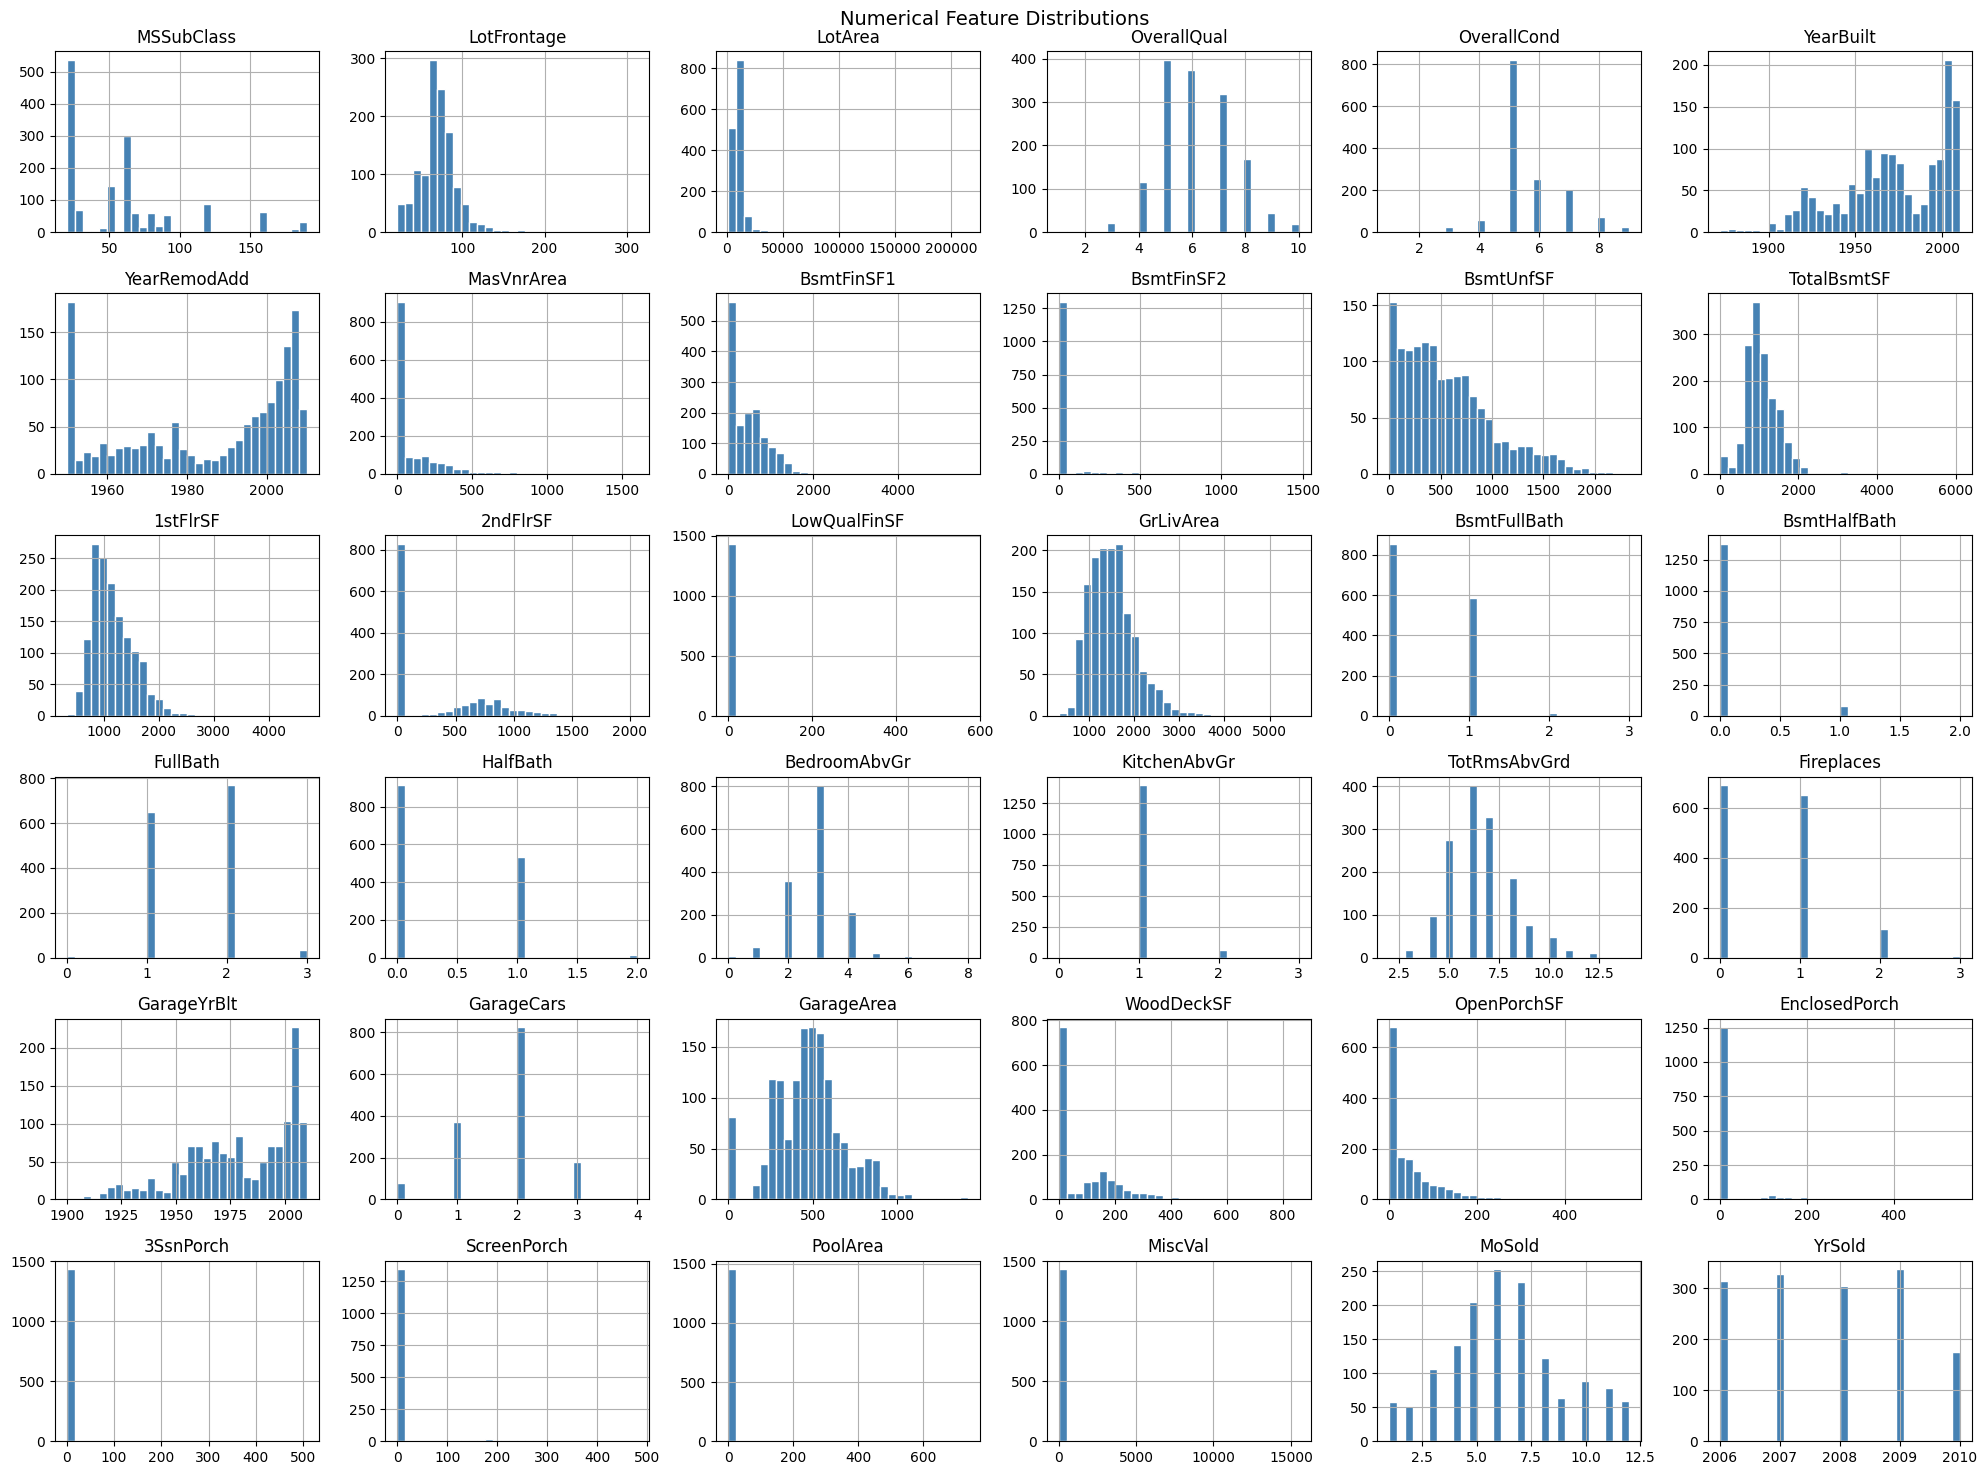

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.drop('SalePrice')
df[num_cols].hist(figsize=(20, 15), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# need to log transform LotArea , MasVnrArea , BsmntFinSF1 , BsmtFinSF2 , LowQualFinSF ,
#  OpenPorchSF, EnclosedPorch as they are all right skewed      

#### 3D Corellation Matrix of Top 20 Features Vs Target

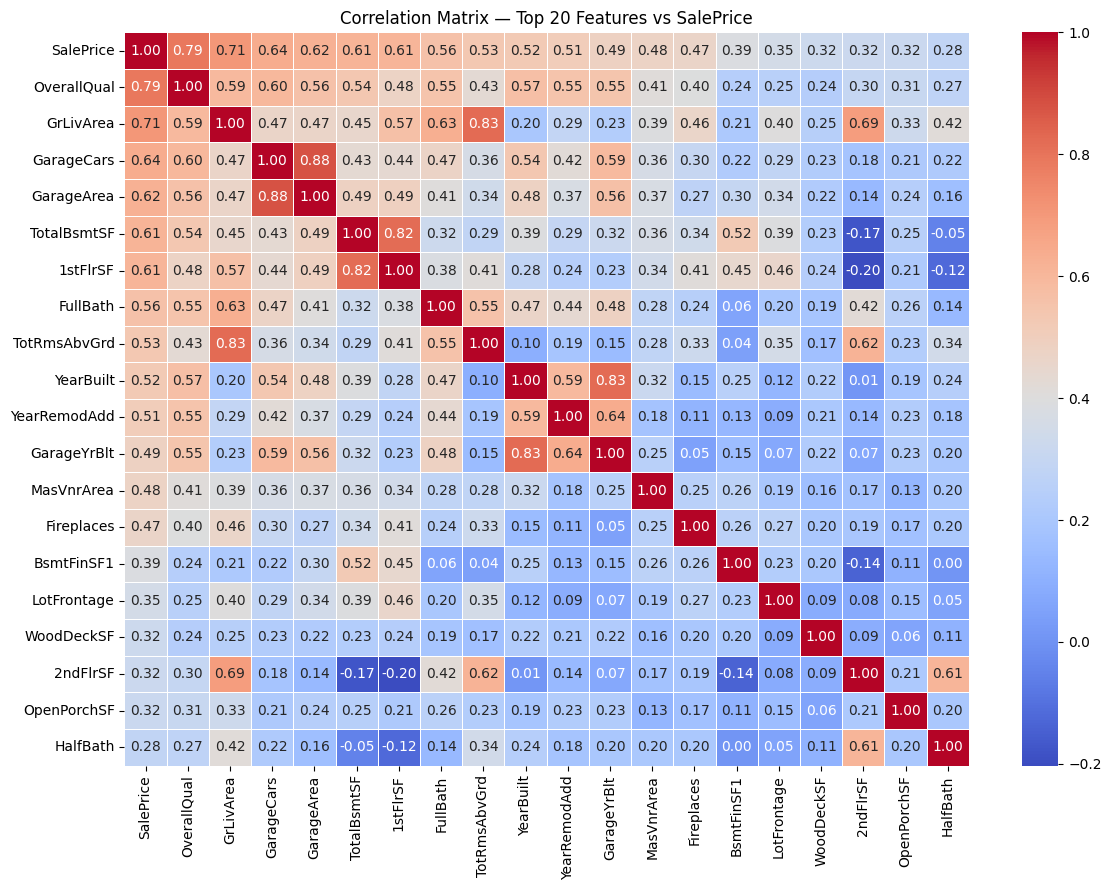

In [10]:
# Finding correlation between features 

num_cols = df.select_dtypes(include=np.number).columns.drop('SalePrice')
corr = df[num_cols.tolist() + ['SalePrice']].corr()
top_corr_features = corr['SalePrice'].abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12, 9))
sns.heatmap(
    df[top_corr_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Matrix — Top 20 Features vs SalePrice')
plt.tight_layout()
plt.show()

#### 3E Multicollinearity Check

In [11]:
threshold = 0.85
feature_corr = corr.drop('SalePrice').drop('SalePrice' , axis = 1)

high_corr_pairs = []
cols_list = feature_corr.columns.to_list()

for i in range(len(cols_list)):
    for j in range(i+1 , len(cols_list)):
        val = abs(feature_corr.iloc[i,j])
        if val > threshold:
            high_corr_pairs.append((cols_list[i], cols_list[j], round(val, 2)))

print(f"\nHighly correlated feature pairs (>{threshold}):")
for a, b, v in high_corr_pairs:
    print(f"  {a} vs {b}: {v}")

# We can remove one of the features during cleaning as they both are providing almost same information
# We remove the one which has the least correlation with target variable among those two


Highly correlated feature pairs (>0.85):
  GarageCars vs GarageArea: 0.88


#### 3F Outlier Detection

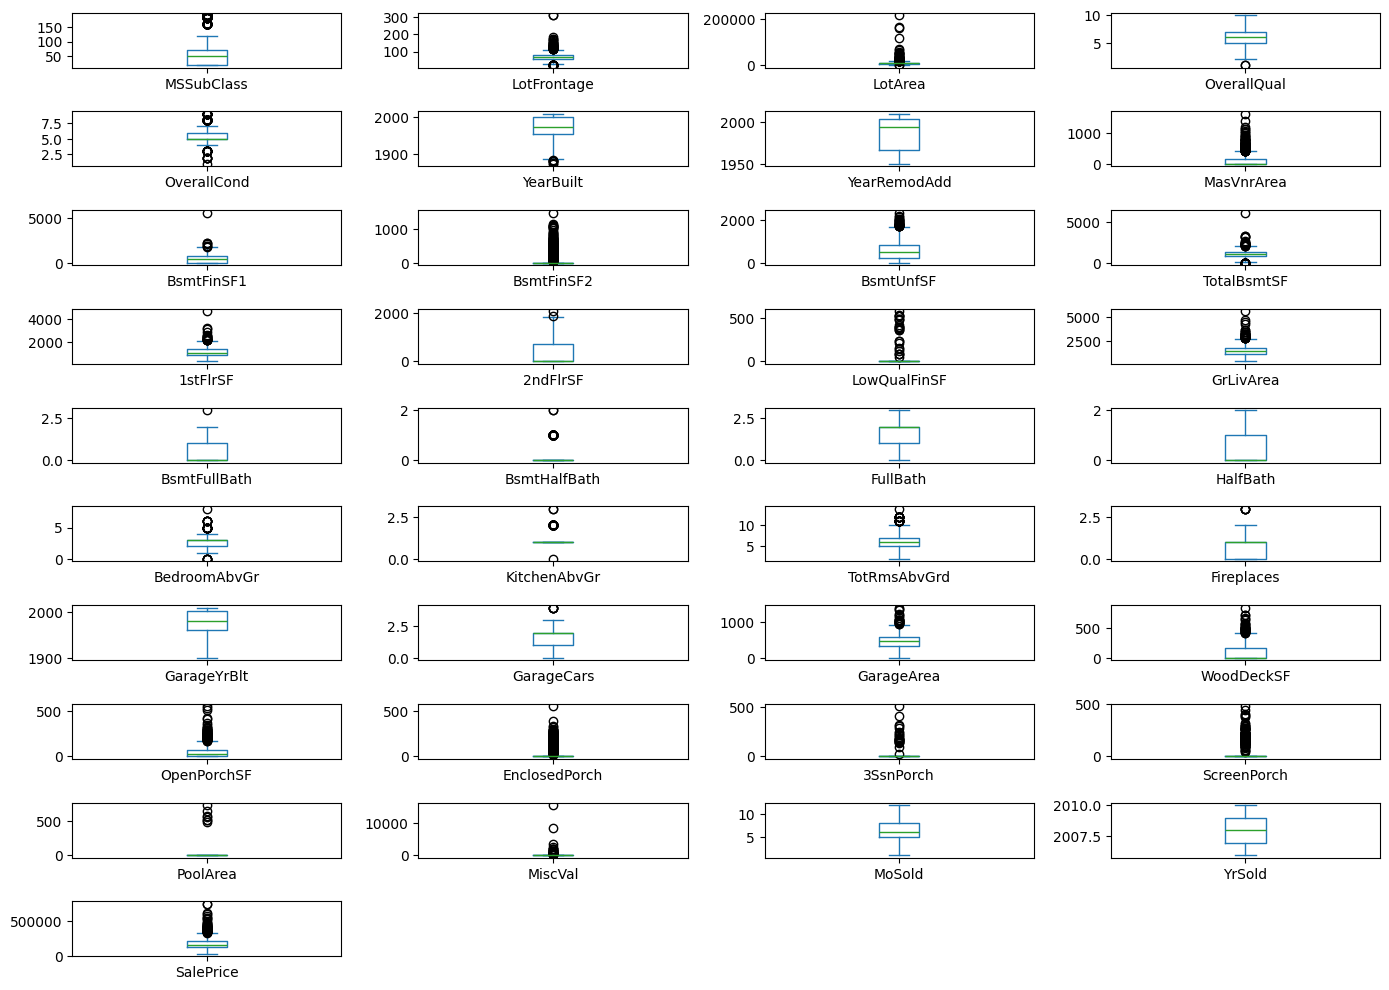

In [12]:
# Finding Outliers 

num_cols = df.select_dtypes(include=np.number).columns

n = len(num_cols)        # total number of numerical columns
cols = 4                 # how many plots per row (your choice)
rows = (n + cols - 1) // cols  # enough rows to fit all columns

df[num_cols].plot(kind= 'box' , subplots= True , layout= (rows , cols) , figsize=(14 ,10))
plt.tight_layout()
plt.show()

## 4.Clean the Data

#### 4A. Changing DataTypes

In [13]:
# Changing Datatypes observed in 3A

df['MSSubClass'] = df['MSSubClass'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)


#### 4B. Handling Null Values

In [14]:
# Handling Null Values

# These are called None value columns because None itself is the information , None in PoolQC means there is no pool. 
none_fill_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
                  'GarageType','GarageFinish','GarageQual','GarageCond',
                  'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
                  'BsmtFinType2','MasVnrType']

for i in none_fill_cols:
    if i in df.columns:
       df[i] = df[i].fillna('None')


# A similar logic but on numerical cols where we can fill the nulls with 0 which acts as information

Zero_fill_cols = ['GarageYrBlt','GarageArea','GarageCars',
                  'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
                  'BsmtFullBath','BsmtHalfBath','MasVnrArea']

for i in Zero_fill_cols:
    if i in Zero_fill_cols:
        df[i] = df[i].fillna(0)

# Now for remaining numerical and categorical columns we impute median and mode respectively

for i in df.select_dtypes(include= np.number).columns:
    df[i] = df[i].fillna(df[i].median())

for i in df.select_dtypes(include= 'object').columns:
    df[i] = df[i].fillna(df[i].mode())

#### 4C. Log Transforming Target Value

In [15]:
df['SalePrice'] = np.log1p(df['SalePrice'])
print(f"SalePrice skewness after log: {df['SalePrice'].skew():.2f}")

SalePrice skewness after log: 0.12


#### 4D. Log Transforming Numerical Skewed Variables

In [16]:
num_cols = df.select_dtypes(include=np.number).columns.drop('SalePrice')

# Checking skewness again for all numerical columns
skewness = df[num_cols].apply(lambda x: x.skew())

right_skewed = skewness[skewness > 1].index.tolist()
left_skewed  = skewness[skewness < -1].index.tolist()

print(f"Right skewed ({len(right_skewed)}): {right_skewed}")
print(f"Left skewed  ({len(left_skewed)}):  {left_skewed}")

# log transforming right skewed values

for i in right_skewed:
    if df[i].min() >=0:
        df[i] = np.log1p(df[i])

# log tranforming left skewd values 

for i in left_skewed:
    if i not in right_skewed:
        df[i] = np.log1p(df[i].max() - df[i])


Right skewed (18): ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF', '1stFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']
Left skewed  (1):  ['GarageYrBlt']


## 5. Train/Test Split

In [17]:
Target = 'SalePrice'

X = df.drop(columns=Target)
y = df[Target]

# First splitting train and temp 

X_Train , X_Temp , y_train , y_temp = train_test_split(X , y , test_size=0.3 , random_state=42)

# Now Splitting Val and Test Dataset

X_Val , X_Test , y_val , y_test = train_test_split(X_Temp , y_temp , test_size=0.5 , random_state=42)

print(f"\n Train : {X_Train.shape} | Val : {X_Val.shape} | Test : {X_Test.shape}")



 Train : (1022, 79) | Val : (219, 79) | Test : (219, 79)


## 6. Feature Engineering

#### 6A. Creating New Features From Existing Features

In [18]:
# Creating new features using existing features

for dataset in [X_Train, X_Val, X_Test]:
    dataset['TotalBath'] = (dataset['FullBath'] + dataset['BsmtFullBath'] +
                            0.5 * dataset['HalfBath'] + 0.5 * dataset['BsmtHalfBath'])
    dataset['TotalSF'] = dataset['TotalBsmtSF'] + dataset['1stFlrSF'] + dataset['2ndFlrSF']
    dataset['HouseAge'] = dataset['YrSold'] - dataset['YearBuilt']
    dataset['YearsSinceRemodel'] = dataset['YrSold'] - dataset['YearRemodAdd']
    dataset['HasGarage'] = (dataset['GarageArea'] > 0).astype(int)
    dataset['HasPool']   = (dataset['PoolArea'] > 0).astype(int)
    dataset['HasBsmt']   = (dataset['TotalBsmtSF'] > 0).astype(int)

#### 6B. Encoding Categorical Values

In [19]:
# Using ordinal encoding for categorical values based on the feature respectively.

cat_cols = X_Train.select_dtypes(include='object').columns.tolist()
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_Train[cat_cols] = enc.fit_transform(X_Train[cat_cols].astype(str))
X_Val[cat_cols]   = enc.transform(X_Val[cat_cols].astype(str))
X_Test[cat_cols]  = enc.transform(X_Test[cat_cols].astype(str))

#### 6C. Dropping a feature in Multicollinear with lower corelation with respect to Target variable

In [20]:
cols_to_drop = []
for a, b, v in high_corr_pairs:
    # Keep the one more correlated with SalePrice (using train only)
    corr_a = abs(X_Train[a].corr(y_train)) if a in X_Train.columns else 0
    corr_b = abs(X_Train[b].corr(y_train)) if b in X_Train.columns else 0
    drop_col = a if corr_a < corr_b else b
    if drop_col not in cols_to_drop and drop_col in X_Train.columns:
        cols_to_drop.append(drop_col)

if cols_to_drop:
    X_Train = X_Train.drop(columns=cols_to_drop)
    X_Val   = X_Val.drop(columns=cols_to_drop)
    X_Test  = X_Test.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} multicollinear columns: {cols_to_drop}")
else:
    print("No multicollinear columns to drop.")

Dropped 1 multicollinear columns: ['GarageArea']


## 7. Scaling the Feature Values

- Similar to encoding we scale the Train dataset and fit is for test and val dataset.

In [23]:
# Scaling feature values

scaler = StandardScaler()
X_Train_scaled = scaler.fit_transform(X_Train)
X_Val_scaled = scaler.transform(X_Val)
X_Test_scaled = scaler.transform(X_Test)

print(f'The Scaling is done for all the 3 sets')


The Scaling is done for all the 3 sets


## 8. Building and Training Models And (Validating on Validation Dataset)

In [32]:
# Building multiple models and will be using the top 2 with best baseline score

models = {
'Ridge' : Ridge(alpha=10)
,'Lasso' : Lasso(alpha=0.001 , max_iter=5000)
,'Random Forest Regressior' : RandomForestRegressor(n_estimators=1000 , random_state=42 , n_jobs= -1)
, 'Gradient Boosting Regressor' : GradientBoostingRegressor(n_estimators=100 , random_state=42)
}


results       = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_Train_scaled, y_train)
    y_pred = model.predict(X_Val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2   = r2_score(y_val, y_pred)
    results[name]        = {'rmse': rmse, 'r2': r2, 'preds': y_pred}
    trained_models[name] = model
    print(f"  {name:<22} RMSE: {rmse:.4f}  |  R²: {r2:.4f}")

best_name  = min(results, key=lambda x: results[x]['rmse'])
best_model = trained_models[best_name]
y_val_pred = results[best_name]['preds']


# Evaluating Lasso Regression as it has lowest RMSE and Highest R2


  Ridge                  RMSE: 0.1364  |  R²: 0.8941
  Lasso                  RMSE: 0.1342  |  R²: 0.8975
  Random Forest Regressior RMSE: 0.1439  |  R²: 0.8821
  Gradient Boosting Regressor RMSE: 0.1406  |  R²: 0.8874


## 9.Generalization Check(Using Test Data)

In [ ]:
# Checking the generalization for Random Forest Regressor

y_test_pred = best_model.predict(X_Test_scaled)

val_rmse  = results[best_name]['rmse']
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
gap       = abs(val_rmse - test_rmse)

print(f"  Val RMSE:  {val_rmse:.4f}")
print(f"  Test RMSE: {test_rmse:.4f}")
print(f"  Gap:       {gap:.4f} ")



  Val RMSE:  0.1342
  Test RMSE: 0.1395
  Gap:       0.0054  ← ideally < 0.01
